In [ ]:
import time

start_time = time.time()
print(f"Start time recorded: {start_time}")

Start time recorded: 1764659102.9609418


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/02_finetune_with_crf_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [1]:
# @markdown package install
do = False # @param{type:"boolean"}
if do:
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq

## ⭐ Setup
You must run all codes under this category.

In [12]:
if do:
    !git clone https://github.com/phonchi/CryoParticleSegment.git

    !wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
    !wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
    !wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
    !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

In [14]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

> #### ⚠ Notice
>
> You need to restart the kernel after the compilation step. Additionally, if your GPU architecture differs, you may need to modify the file at `/content/CryoParticleSegment/Modeling/CRF_main/setup.py`. (We attempt to detect the GPU configuration automatically, so this step is usually not necessary.)
> Furthermore, depending on the number of classes and other parameters, you may encounter an error that requires adjusting the file at `/content/CryoParticleSegment/Modeling/CRF_main/src/PermutohedralFiltering/source/gpu/LatticeFilter.cu`:
>
> 1. Note the `pd` and `vd` values from the error message.
> 2. Add an `else if (pd == ? && vd == ?)` block.
> 3. Within that block, insert the following line, replacing `pd` and `vd` with the specific values:
>
>    ```cpp
>    latticeFilterGPU<pd, vd>(output_tensor, input_tensor, positions, num_super_pixels, backward);
>    ```
> 4. Recompile using `setup.py`.

In [3]:
if do:
    #!git clone https://github.com/netw0rkf10w/CRF.git
    %cd CryoParticleSegment/Modeling/CRF_main
    !python setup.py clean --all
    !rm -rf build/
    !python setup.py build_ext --inplace --force
    !python setup.py install

    crf_path = os.path.join(os.getcwd(), 'CRF')
    if crf_path not in sys.path:
        sys.path.insert(0, crf_path)

    print(f"Added {crf_path} to the Python path.")

In [4]:
%cd /content/

/content


### ✅ Directory Settings

In [5]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [6]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---

LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
        if dnzd_pw == True:
            !cp -r {DENOISED_IMAGE_DIR} /content/denoised_image_dir
            DENOISED_IMAGE_DIR = "/content/denoised_image_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ✅ Packages Handling

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

In [15]:
from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched, collate_fn
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [16]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [17]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 100
BATCH = 2
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [19]:
crop = transforms.CenterCrop(3840)

In [20]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [21]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [22]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [23]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Convcrf wtih FCN finetuned on cryoem

## The model

### ✅ Model

Currently, we only test `fw` and `mf` solver as described in the paper. You could set `use_unary_only` to `True` to obtained CD-CRF, while setting `False` return to traditional CRF.

In [24]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = False # @param {type:"boolean"}
loss = "dice" # @param {type:"string"}

In [25]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [30]:
# @markdown input the dir_name where you store the model in best notebook  01
dir_name = "unet_eb5_dice" # @param {type:"string"}
CHECKPOINT_PATH = os.path.dirname(RESULT_DIR.rstrip(os.path.sep)) + f"/{dir_name}"

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice/checkpoint42.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice/checkpoint42.pt


In [31]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=use_unary_only)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


In [32]:
params = [
    {'params': model.backbone.parameters(), 'lr': 1e-5},  # Lower learning rate for fine-tuning the backbone
    {'params': crf.parameters(), 'lr': 1e-3}         # Higher learning rate for training the CRF from scratch
]

In [33]:
print(model_post)

ModelWithFWCRF(
  (backbone): UnetPlusPlus(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn1): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (g

In [34]:
from torchinfo import summary
summary(model_post, input_size=(BATCH, 1, 512, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
ModelWithFWCRF                                          [2, 2, 512, 512]          --
├─UnetPlusPlus: 1-1                                     [2, 2, 512, 512]          --
│    └─EfficientNetEncoder: 2-1                         [2, 1, 512, 512]          1,052,672
│    │    └─Conv2d: 3-1                                 [2, 48, 256, 256]         432
│    │    └─BatchNormAct2d: 3-2                         [2, 48, 256, 256]         96
│    │    └─Sequential: 3-3                             --                        27,286,720
│    └─UnetPlusPlusDecoder: 2-2                         [2, 16, 512, 512]         --
│    │    └─ModuleDict: 3-4                             --                        3,569,152
│    └─SegmentationHead: 2-3                            [2, 2, 512, 512]          --
│    │    └─Conv2d: 3-5                                 [2, 2, 512, 512]          290
│    │    └─Identity: 3-6           

In [35]:
import math
if loss == "dice":
    criterion = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "cross_entropy":
    criterion = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
elif loss == "jaccard":
    criterion = smp.losses.JaccardLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Lovasz":
    criterion = smp.losses.LovaszLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Tversky":
    criterion = smp.losses.TverskyLoss(smp.losses.MULTICLASS_MODE, from_logits=True, alpha=0.7, beta=0.3, gamma=1, smooth=0.1)
else:
    print("Loss not supported")
    raise NotImplementedError
optimizer = torch.optim.Adam(params)
#scheduler = ReduceLROnPlateau(optimizer, patience=RLR_PATIENCE, verbose=True)
#scheduler = OneCycleLR(optimizer, max_lr=LR, verbose=True, steps_per_epoch=math.ceil(len(train_dataset)/BATCH), epochs=EPOCHS)

In [36]:
!mkdir -p {RESULT_DIR}

In [37]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

### ✅ Training

In [38]:
# Unet++ eb5 CDCRF fw
Trainer = tqdm_plugin_for_Trainer(CryoEMTrainerWithScheduler)
trainer = Trainer(model_post, train_dataset, criterion, optimizer, DEVICE,
              num_classes = NUM_CLASSES, patience=ES_PATIENCE)

trainer.train(EPOCHS, val_loader=val_loader, batch_size = BATCH,
              ckpt_dir = RESULT_DIR, random_state = random_state)

Epoch   1/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1453
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000044
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000048
tensor([[ 9.9926e-01, -8.3530e-04],
        [ 7.3850e-04,  1.0008e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 1.000131
Epoch 1: W1(Appearance) Off_Diag_Mean -> -0.000135
tensor([[ 9.9929e-01, -9.7545e-04],
        [ 7.0523e-04,  1.0010e+00]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1624
Iou by Class: [0.87101096 0.61691695]
Precision by Class: [0.9366554 0.7477251]
Recall by Class: [0.92552936 0.7790747 ]
Accuracy by Class: [0.89319664 0.89319664]
F1_score by Class: [0.9310592  0.76307803]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.16237853467464447.
Epoch   2/100:


...

Validation score:
  loss : 0.1549
Iou by Class: [0.8746188 0.6338761]
Precision by Class: [0.9442703  0.74637914]
Recall by Class: [0.922223  0.8078891]
Accuracy by Class: [0.89698154 0.89698154]
F1_score by Class: [0.93311644 0.775917  ]
No improvement for 14 epoch.
Epoch  76/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1264
Epoch 76: W2(Smoothness) Diag_Mean -> 1.008695
Epoch 76: W2(Smoothness) Off_Diag_Mean -> -0.008766
tensor([[ 0.9894, -0.0279],
        [ 0.0103,  1.0280]])
Epoch 76: W1(Appearance) Diag_Mean -> 0.998428
Epoch 76: W1(Appearance) Off_Diag_Mean -> 0.001479
tensor([[ 0.9802, -0.0168],
        [ 0.0198,  1.0167]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1552
Iou by Class: [0.8755592 0.6327655]
Precision by Class: [0.94222355 0.75189525]
Recall by Class: [0.9252338  0.79974926]
Accuracy by Class: [0.89753056 0.89753056]
F1_score by Class: [0.9336514 0.7750843]
Early stopping


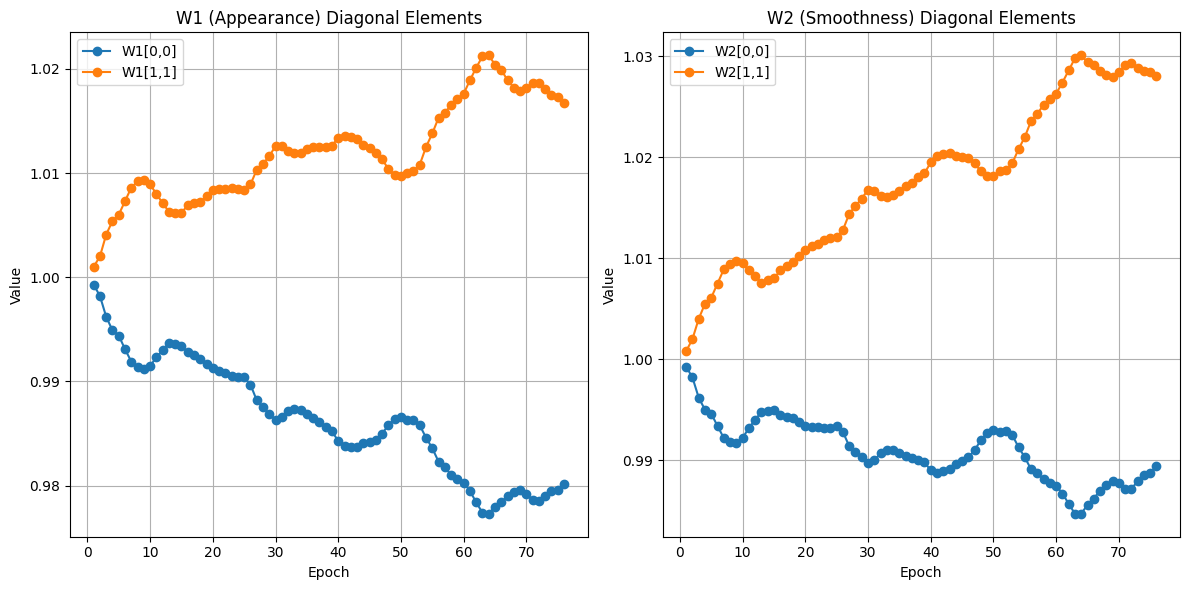

In [4]:
import re
import matplotlib.pyplot as plt

# ... (log_data string containing the log you provided) ...

epochs = []
w1_00 = []
w1_11 = []
w2_00 = []
w2_11 = []

lines = """Epoch   1/100:
Training: 100%
 4/4 [00:06<00:00,  1.64s/it, Loss=0.1110]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1453
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000044
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000048
tensor([[ 9.9926e-01, -8.3530e-04],
        [ 7.3850e-04,  1.0008e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 1.000131
Epoch 1: W1(Appearance) Off_Diag_Mean -> -0.000135
tensor([[ 9.9929e-01, -9.7545e-04],
        [ 7.0523e-04,  1.0010e+00]])
Validation: 100%
 6/6 [00:33<00:00,  5.46s/it]
Validation score:
  loss : 0.1624
Iou by Class: [0.87101096 0.61691695]
Precision by Class: [0.9366554 0.7477251]
Recall by Class: [0.92552936 0.7790747 ]
Accuracy by Class: [0.89319664 0.89319664]
F1_score by Class: [0.9310592  0.76307803]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.16237853467464447.
Epoch   2/100:
Training: 100%
 4/4 [00:06<00:00,  1.51s/it, Loss=0.1119]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1448
Epoch 2: W2(Smoothness) Diag_Mean -> 1.000086
Epoch 2: W2(Smoothness) Off_Diag_Mean -> -0.000092
tensor([[ 0.9982, -0.0020],
        [ 0.0018,  1.0020]])
Epoch 2: W1(Appearance) Diag_Mean -> 1.000108
Epoch 2: W1(Appearance) Off_Diag_Mean -> -0.000114
tensor([[ 0.9982, -0.0020],
        [ 0.0018,  1.0020]])
Validation: 100%
 6/6 [00:32<00:00,  5.44s/it]
Validation score:
  loss : 0.1624
Iou by Class: [0.87165296 0.6165247 ]
Precision by Class: [0.9356206 0.7511285]
Recall by Class: [0.9272686 0.7747946]
Accuracy by Class: [0.89360696 0.89360696]
F1_score by Class: [0.9314259 0.7627779]
No improvement for 1 epoch.
Epoch   3/100:
Training: 100%
 4/4 [00:06<00:00,  1.50s/it, Loss=0.1635]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1338
Epoch 3: W2(Smoothness) Diag_Mean -> 1.000126
Epoch 3: W2(Smoothness) Off_Diag_Mean -> -0.000131
tensor([[ 0.9962, -0.0040],
        [ 0.0038,  1.0040]])
Epoch 3: W1(Appearance) Diag_Mean -> 1.000121
Epoch 3: W1(Appearance) Off_Diag_Mean -> -0.000126
tensor([[ 0.9962, -0.0041],
        [ 0.0038,  1.0041]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1627
Iou by Class: [0.8721548  0.61551917]
Precision by Class: [0.93434423 0.7545996 ]
Recall by Class: [0.929095  0.7695631]
Accuracy by Class: [0.8938751 0.8938751]
F1_score by Class: [0.93171227 0.7620079 ]
No improvement for 2 epoch.
Epoch   4/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1084]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1340
Epoch 4: W2(Smoothness) Diag_Mean -> 1.000243
Epoch 4: W2(Smoothness) Off_Diag_Mean -> -0.000249
tensor([[ 0.9950, -0.0055],
        [ 0.0050,  1.0055]])
Epoch 4: W1(Appearance) Diag_Mean -> 1.000158
Epoch 4: W1(Appearance) Off_Diag_Mean -> -0.000163
tensor([[ 0.9949, -0.0055],
        [ 0.0051,  1.0054]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1623
Iou by Class: [0.872357   0.61620665]
Precision by Class: [0.93456966 0.7548203 ]
Recall by Class: [0.9291017 0.7704079]
Accuracy by Class: [0.89406693 0.89406693]
F1_score by Class: [0.93182766 0.76253444]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint4.pt
Loss improve to 0.16234159469604492.
Epoch   5/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1361]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1399
Epoch 5: W2(Smoothness) Diag_Mean -> 1.000373
Epoch 5: W2(Smoothness) Off_Diag_Mean -> -0.000385
tensor([[ 0.9946, -0.0061],
        [ 0.0053,  1.0061]])
Epoch 5: W1(Appearance) Diag_Mean -> 1.000195
Epoch 5: W1(Appearance) Off_Diag_Mean -> -0.000206
tensor([[ 0.9944, -0.0060],
        [ 0.0056,  1.0060]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1615
Iou by Class: [0.87261534 0.6182509 ]
Precision by Class: [0.93565184 0.7538248 ]
Recall by Class: [0.9283269  0.77465457]
Accuracy by Class: [0.89440066 0.89440066]
F1_score by Class: [0.93197495 0.7640977 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint5.pt
Loss improve to 0.16152982910474142.
Epoch   6/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.2034]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1449
Epoch 6: W2(Smoothness) Diag_Mean -> 1.000466
Epoch 6: W2(Smoothness) Off_Diag_Mean -> -0.000471
tensor([[ 0.9934, -0.0075],
        [ 0.0066,  1.0075]])
Epoch 6: W1(Appearance) Diag_Mean -> 1.000195
Epoch 6: W1(Appearance) Off_Diag_Mean -> -0.000200
tensor([[ 0.9931, -0.0073],
        [ 0.0069,  1.0073]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1617
Iou by Class: [0.8725935 0.6176876]
Precision by Class: [0.9352935  0.75433564]
Recall by Class: [0.92865527 0.7732328 ]
Accuracy by Class: [0.8943427 0.8943427]
F1_score by Class: [0.93196255 0.76366735]
No improvement for 1 epoch.
Epoch   7/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1074]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1303
Epoch 7: W2(Smoothness) Diag_Mean -> 1.000537
Epoch 7: W2(Smoothness) Off_Diag_Mean -> -0.000535
tensor([[ 0.9922, -0.0089],
        [ 0.0078,  1.0089]])
Epoch 7: W1(Appearance) Diag_Mean -> 1.000240
Epoch 7: W1(Appearance) Off_Diag_Mean -> -0.000237
tensor([[ 0.9919, -0.0086],
        [ 0.0082,  1.0086]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1613
Iou by Class: [0.87277377 0.6184298 ]
Precision by Class: [0.93558425 0.7543871 ]
Recall by Class: [0.9285727  0.77434206]
Accuracy by Class: [0.8945233 0.8945233]
F1_score by Class: [0.93206537 0.76423424]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint7.pt
Loss improve to 0.16132974127928415.
Epoch   8/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1152]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1439
Epoch 8: W2(Smoothness) Diag_Mean -> 1.000603
Epoch 8: W2(Smoothness) Off_Diag_Mean -> -0.000602
tensor([[ 0.9918, -0.0094],
        [ 0.0082,  1.0094]])
Epoch 8: W1(Appearance) Diag_Mean -> 1.000291
Epoch 8: W1(Appearance) Off_Diag_Mean -> -0.000289
tensor([[ 0.9914, -0.0092],
        [ 0.0086,  1.0092]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1601
Iou by Class: [0.8726831 0.6216514]
Precision by Class: [0.93791926 0.750473  ]
Recall by Class: [0.92618185 0.7836219 ]
Accuracy by Class: [0.89470893 0.89470893]
F1_score by Class: [0.9320136 0.7666893]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint8.pt
Loss improve to 0.16009794175624847.
Epoch   9/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1292]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1318
Epoch 9: W2(Smoothness) Diag_Mean -> 1.000717
Epoch 9: W2(Smoothness) Off_Diag_Mean -> -0.000722
tensor([[ 0.9917, -0.0097],
        [ 0.0083,  1.0097]])
Epoch 9: W1(Appearance) Diag_Mean -> 1.000226
Epoch 9: W1(Appearance) Off_Diag_Mean -> -0.000230
tensor([[ 0.9912, -0.0093],
        [ 0.0088,  1.0093]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1596
Iou by Class: [0.87242764 0.6232292 ]
Precision by Class: [0.9393436  0.74761826]
Recall by Class: [0.9245103 0.7892878]
Accuracy by Class: [0.8946573 0.8946573]
F1_score by Class: [0.931868  0.7678881]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint9.pt
Loss improve to 0.15959096451600394.
Epoch  10/100:
Training: 100%
 4/4 [00:06<00:00,  1.51s/it, Loss=0.1565]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1221
Epoch 10: W2(Smoothness) Diag_Mean -> 1.000860
Epoch 10: W2(Smoothness) Off_Diag_Mean -> -0.000876
tensor([[ 0.9922, -0.0095],
        [ 0.0078,  1.0095]])
Epoch 10: W1(Appearance) Diag_Mean -> 1.000228
Epoch 10: W1(Appearance) Off_Diag_Mean -> -0.000244
tensor([[ 0.9915, -0.0089],
        [ 0.0084,  1.0089]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1586
Iou by Class: [0.8722791 0.6262373]
Precision by Class: [0.94168395 0.743819  ]
Recall by Class: [0.92208844 0.7984506 ]
Accuracy by Class: [0.8947929 0.8947929]
F1_score by Class: [0.93178326 0.7701672 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint10.pt
Loss improve to 0.1585878978172938.
Epoch  11/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1133]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1205
Epoch 11: W2(Smoothness) Diag_Mean -> 1.000968
Epoch 11: W2(Smoothness) Off_Diag_Mean -> -0.001001
tensor([[ 0.9932, -0.0088],
        [ 0.0068,  1.0088]])
Epoch 11: W1(Appearance) Diag_Mean -> 1.000141
Epoch 11: W1(Appearance) Off_Diag_Mean -> -0.000175
tensor([[ 0.9923, -0.0080],
        [ 0.0077,  1.0080]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1585
Iou by Class: [0.87211895 0.62641716]
Precision by Class: [0.9420172 0.7429208]
Recall by Class: [0.9215903 0.7997814]
Accuracy by Class: [0.89469856 0.89469856]
F1_score by Class: [0.93169177 0.7703032 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint11.pt
Loss improve to 0.1585390418767929.
Epoch  12/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1307]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1369
Epoch 12: W2(Smoothness) Diag_Mean -> 1.001067
Epoch 12: W2(Smoothness) Off_Diag_Mean -> -0.001112
tensor([[ 0.9940, -0.0082],
        [ 0.0060,  1.0082]])
Epoch 12: W1(Appearance) Diag_Mean -> 1.000020
Epoch 12: W1(Appearance) Off_Diag_Mean -> -0.000067
tensor([[ 0.9930, -0.0071],
        [ 0.0070,  1.0071]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1582
Iou by Class: [0.87214166 0.6273597 ]
Precision by Class: [0.94267505 0.74206114]
Recall by Class: [0.9209869  0.80232096]
Accuracy by Class: [0.89478904 0.89478904]
F1_score by Class: [0.9317048 0.7710155]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint12.pt
Loss improve to 0.1582004278898239.
Epoch  13/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1243]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1278
Epoch 13: W2(Smoothness) Diag_Mean -> 1.001194
Epoch 13: W2(Smoothness) Off_Diag_Mean -> -0.001250
tensor([[ 0.9948, -0.0076],
        [ 0.0051,  1.0076]])
Epoch 13: W1(Appearance) Diag_Mean -> 0.999966
Epoch 13: W1(Appearance) Off_Diag_Mean -> -0.000023
tensor([[ 0.9937, -0.0063],
        [ 0.0063,  1.0063]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1584
Iou by Class: [0.87283635 0.6262122 ]
Precision by Class: [0.9409622 0.7463551]
Recall by Class: [0.92340523 0.79550815]
Accuracy by Class: [0.8951694 0.8951694]
F1_score by Class: [0.9321011  0.77014816]
No improvement for 1 epoch.
Epoch  14/100:
Training: 100%
 4/4 [00:06<00:00,  1.51s/it, Loss=0.1715]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1286
Epoch 14: W2(Smoothness) Diag_Mean -> 1.001352
Epoch 14: W2(Smoothness) Off_Diag_Mean -> -0.001412
tensor([[ 0.9949, -0.0078],
        [ 0.0050,  1.0078]])
Epoch 14: W1(Appearance) Diag_Mean -> 0.999906
Epoch 14: W1(Appearance) Off_Diag_Mean -> 0.000032
tensor([[ 0.9936, -0.0063],
        [ 0.0064,  1.0062]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1596
Iou by Class: [0.87254727 0.623037  ]
Precision by Class: [0.93905973 0.74837035]
Recall by Class: [0.9249199 0.7881437]
Accuracy by Class: [0.89472383 0.89472383]
F1_score by Class: [0.9319362  0.76774216]
No improvement for 2 epoch.
Epoch  15/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1166]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1237
Epoch 15: W2(Smoothness) Diag_Mean -> 1.001492
Epoch 15: W2(Smoothness) Off_Diag_Mean -> -0.001556
tensor([[ 0.9950, -0.0080],
        [ 0.0049,  1.0080]])
Epoch 15: W1(Appearance) Diag_Mean -> 0.999804
Epoch 15: W1(Appearance) Off_Diag_Mean -> 0.000130
tensor([[ 0.9934, -0.0062],
        [ 0.0065,  1.0062]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1593
Iou by Class: [0.87277526 0.6239606 ]
Precision by Class: [0.93943083 0.74844354]
Recall by Class: [0.9248161  0.78954065]
Accuracy by Class: [0.89495134 0.89495134]
F1_score by Class: [0.9320662  0.76844305]
No improvement for 3 epoch.
Epoch  16/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1435]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1310
Epoch 16: W2(Smoothness) Diag_Mean -> 1.001630
Epoch 16: W2(Smoothness) Off_Diag_Mean -> -0.001693
tensor([[ 0.9945, -0.0089],
        [ 0.0055,  1.0088]])
Epoch 16: W1(Appearance) Diag_Mean -> 0.999828
Epoch 16: W1(Appearance) Off_Diag_Mean -> 0.000107
tensor([[ 0.9928, -0.0069],
        [ 0.0072,  1.0069]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1587
Iou by Class: [0.87359804 0.62500477]
Precision by Class: [0.9391466 0.7511469]
Recall by Class: [0.9260162 0.7882145]
Accuracy by Class: [0.8955937 0.8955937]
F1_score by Class: [0.93253523 0.7692344 ]
No improvement for 4 epoch.
Epoch  17/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1158]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1291
Epoch 17: W2(Smoothness) Diag_Mean -> 1.001751
Epoch 17: W2(Smoothness) Off_Diag_Mean -> -0.001816
tensor([[ 0.9943, -0.0093],
        [ 0.0056,  1.0092]])
Epoch 17: W1(Appearance) Diag_Mean -> 0.999764
Epoch 17: W1(Appearance) Off_Diag_Mean -> 0.000169
tensor([[ 0.9925, -0.0071],
        [ 0.0075,  1.0071]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1591
Iou by Class: [0.8739467 0.6236756]
Precision by Class: [0.93778056 0.754241  ]
Recall by Class: [0.92774105 0.7827412 ]
Accuracy by Class: [0.8957294 0.8957294]
F1_score by Class: [0.93273383 0.76822686]
No improvement for 5 epoch.
Epoch  18/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1027]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1335
Epoch 18: W2(Smoothness) Diag_Mean -> 1.001873
Epoch 18: W2(Smoothness) Off_Diag_Mean -> -0.001938
tensor([[ 0.9942, -0.0096],
        [ 0.0058,  1.0096]])
Epoch 18: W1(Appearance) Diag_Mean -> 0.999686
Epoch 18: W1(Appearance) Off_Diag_Mean -> 0.000245
tensor([[ 0.9922, -0.0073],
        [ 0.0078,  1.0072]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1581
Iou by Class: [0.8741759 0.6261224]
Precision by Class: [0.93921554 0.75264984]
Recall by Class: [0.9265984  0.78833723]
Accuracy by Class: [0.8960746 0.8960746]
F1_score by Class: [0.93286437 0.77008027]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint18.pt
Loss improve to 0.15811723470687866.
Epoch  19/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1204]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1301
Epoch 19: W2(Smoothness) Diag_Mean -> 1.002006
Epoch 19: W2(Smoothness) Off_Diag_Mean -> -0.002070
tensor([[ 0.9938, -0.0103],
        [ 0.0062,  1.0102]])
Epoch 19: W1(Appearance) Diag_Mean -> 0.999724
Epoch 19: W1(Appearance) Off_Diag_Mean -> 0.000210
tensor([[ 0.9917, -0.0078],
        [ 0.0083,  1.0078]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1590
Iou by Class: [0.8743464 0.6236423]
Precision by Class: [0.9372652  0.75619507]
Recall by Class: [0.9286968 0.7805956]
Accuracy by Class: [0.8960005 0.8960005]
F1_score by Class: [0.93296134 0.76820165]
No improvement for 1 epoch.
Epoch  20/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1032]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1283
Epoch 20: W2(Smoothness) Diag_Mean -> 1.002140
Epoch 20: W2(Smoothness) Off_Diag_Mean -> -0.002202
tensor([[ 0.9934, -0.0109],
        [ 0.0065,  1.0108]])
Epoch 20: W1(Appearance) Diag_Mean -> 0.999824
Epoch 20: W1(Appearance) Off_Diag_Mean -> 0.000112
tensor([[ 0.9913, -0.0084],
        [ 0.0087,  1.0084]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1583
Iou by Class: [0.87424254 0.62547684]
Precision by Class: [0.93867666 0.7536711 ]
Recall by Class: [0.92719847 0.78619975]
Accuracy by Class: [0.89607024 0.89607024]
F1_score by Class: [0.9329023  0.76959187]
No improvement for 2 epoch.
Epoch  21/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1043]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1397
Epoch 21: W2(Smoothness) Diag_Mean -> 1.002245
Epoch 21: W2(Smoothness) Off_Diag_Mean -> -0.002307
tensor([[ 0.9933, -0.0112],
        [ 0.0066,  1.0112]])
Epoch 21: W1(Appearance) Diag_Mean -> 0.999785
Epoch 21: W1(Appearance) Off_Diag_Mean -> 0.000150
tensor([[ 0.9910, -0.0086],
        [ 0.0089,  1.0085]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1579
Iou by Class: [0.87385976 0.62682337]
Precision by Class: [0.9401107  0.75040996]
Recall by Class: [0.9253743  0.79192805]
Accuracy by Class: [0.8959134 0.8959134]
F1_score by Class: [0.93268436 0.7706102 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint21.pt
Loss improve to 0.15790312985579172.
Epoch  22/100:
Training: 100%
 4/4 [00:06<00:00,  1.51s/it, Loss=0.1120]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1249
Epoch 22: W2(Smoothness) Diag_Mean -> 1.002351
Epoch 22: W2(Smoothness) Off_Diag_Mean -> -0.002413
tensor([[ 0.9933, -0.0115],
        [ 0.0066,  1.0114]])
Epoch 22: W1(Appearance) Diag_Mean -> 0.999639
Epoch 22: W1(Appearance) Off_Diag_Mean -> 0.000296
tensor([[ 0.9908, -0.0085],
        [ 0.0091,  1.0085]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1582
Iou by Class: [0.87382305 0.62594944]
Precision by Class: [0.9395348  0.75118035]
Recall by Class: [0.9258918  0.78968066]
Accuracy by Class: [0.8958205 0.8958205]
F1_score by Class: [0.93266344 0.76994944]
No improvement for 1 epoch.
Epoch  23/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1123]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1292
Epoch 23: W2(Smoothness) Diag_Mean -> 1.002469
Epoch 23: W2(Smoothness) Off_Diag_Mean -> -0.002530
tensor([[ 0.9932, -0.0118],
        [ 0.0068,  1.0118]])
Epoch 23: W1(Appearance) Diag_Mean -> 0.999557
Epoch 23: W1(Appearance) Off_Diag_Mean -> 0.000379
tensor([[ 0.9905, -0.0087],
        [ 0.0094,  1.0086]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1572
Iou by Class: [0.8738516 0.6285346]
Precision by Class: [0.94135004 0.7485418 ]
Recall by Class: [0.92416745 0.7967674 ]
Accuracy by Class: [0.8960414 0.8960414]
F1_score by Class: [0.9326796 0.771902 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint23.pt
Loss improve to 0.15724045038223267.
Epoch  24/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1405]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1558
Epoch 24: W2(Smoothness) Diag_Mean -> 1.002611
Epoch 24: W2(Smoothness) Off_Diag_Mean -> -0.002672
tensor([[ 0.9932, -0.0120],
        [ 0.0067,  1.0120]])
Epoch 24: W1(Appearance) Diag_Mean -> 0.999442
Epoch 24: W1(Appearance) Off_Diag_Mean -> 0.000492
tensor([[ 0.9904, -0.0086],
        [ 0.0095,  1.0085]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1574
Iou by Class: [0.8736842 0.6281056]
Precision by Class: [0.9412532  0.74822944]
Recall by Class: [0.9240736  0.79643166]
Accuracy by Class: [0.8958941 0.8958941]
F1_score by Class: [0.9325843  0.77157843]
No improvement for 1 epoch.
Epoch  25/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1078]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1275
Epoch 25: W2(Smoothness) Diag_Mean -> 1.002718
Epoch 25: W2(Smoothness) Off_Diag_Mean -> -0.002781
tensor([[ 0.9934, -0.0121],
        [ 0.0066,  1.0121]])
Epoch 25: W1(Appearance) Diag_Mean -> 0.999399
Epoch 25: W1(Appearance) Off_Diag_Mean -> 0.000534
tensor([[ 0.9904, -0.0085],
        [ 0.0096,  1.0084]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1577
Iou by Class: [0.8741322  0.62690455]
Precision by Class: [0.9398257 0.7515939]
Recall by Class: [0.92595625 0.790743  ]
Accuracy by Class: [0.89610523 0.89610523]
F1_score by Class: [0.9328394  0.77067155]
No improvement for 2 epoch.
Epoch  26/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1226]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1457
Epoch 26: W2(Smoothness) Diag_Mean -> 1.002813
Epoch 26: W2(Smoothness) Off_Diag_Mean -> -0.002871
tensor([[ 0.9928, -0.0128],
        [ 0.0071,  1.0128]])
Epoch 26: W1(Appearance) Diag_Mean -> 0.999312
Epoch 26: W1(Appearance) Off_Diag_Mean -> 0.000625
tensor([[ 0.9897, -0.0090],
        [ 0.0102,  1.0089]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1581
Iou by Class: [0.87404853 0.62603587]
Precision by Class: [0.9393139 0.7521437]
Recall by Class: [0.9263596 0.788756 ]
Accuracy by Class: [0.8959809 0.8959809]
F1_score by Class: [0.93279177 0.7700148 ]
No improvement for 3 epoch.
Epoch  27/100:
Training: 100%
 4/4 [00:06<00:00,  1.50s/it, Loss=0.2232]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1498
Epoch 27: W2(Smoothness) Diag_Mean -> 1.002909
Epoch 27: W2(Smoothness) Off_Diag_Mean -> -0.002951
tensor([[ 0.9914, -0.0144],
        [ 0.0085,  1.0144]])
Epoch 27: W1(Appearance) Diag_Mean -> 0.999234
Epoch 27: W1(Appearance) Off_Diag_Mean -> 0.000718
tensor([[ 0.9882, -0.0104],
        [ 0.0118,  1.0103]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1575
Iou by Class: [0.8735151  0.62803864]
Precision by Class: [0.9414199 0.7475263]
Recall by Class: [0.9237239  0.79712206]
Accuracy by Class: [0.895774 0.895774]
F1_score by Class: [0.93248796 0.7715279 ]
No improvement for 4 epoch.
Epoch  28/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1168]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1288
Epoch 28: W2(Smoothness) Diag_Mean -> 1.003017
Epoch 28: W2(Smoothness) Off_Diag_Mean -> -0.003055
tensor([[ 0.9908, -0.0152],
        [ 0.0091,  1.0152]])
Epoch 28: W1(Appearance) Diag_Mean -> 0.999170
Epoch 28: W1(Appearance) Off_Diag_Mean -> 0.000786
tensor([[ 0.9875, -0.0109],
        [ 0.0125,  1.0109]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1577
Iou by Class: [0.87352437 0.6274712 ]
Precision by Class: [0.9409988  0.74816895]
Recall by Class: [0.92414   0.7954803]
Accuracy by Class: [0.89573574 0.89573574]
F1_score by Class: [0.93249327 0.7710996 ]
No improvement for 5 epoch.
Epoch  29/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1153]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1301
Epoch 29: W2(Smoothness) Diag_Mean -> 1.003136
Epoch 29: W2(Smoothness) Off_Diag_Mean -> -0.003170
tensor([[ 0.9903, -0.0159],
        [ 0.0096,  1.0159]])
Epoch 29: W1(Appearance) Diag_Mean -> 0.999259
Epoch 29: W1(Appearance) Off_Diag_Mean -> 0.000703
tensor([[ 0.9869, -0.0117],
        [ 0.0131,  1.0116]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1574
Iou by Class: [0.8732225 0.6285524]
Precision by Class: [0.94216555 0.7456584 ]
Recall by Class: [0.9226803  0.80008924]
Accuracy by Class: [0.89561594 0.89561594]
F1_score by Class: [0.9323212  0.77191544]
No improvement for 6 epoch.
Epoch  30/100:
Training: 100%
 4/4 [00:06<00:00,  1.51s/it, Loss=0.1728]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1223
Epoch 30: W2(Smoothness) Diag_Mean -> 1.003255
Epoch 30: W2(Smoothness) Off_Diag_Mean -> -0.003279
tensor([[ 0.9897, -0.0168],
        [ 0.0102,  1.0168]])
Epoch 30: W1(Appearance) Diag_Mean -> 0.999447
Epoch 30: W1(Appearance) Off_Diag_Mean -> 0.000526
tensor([[ 0.9863, -0.0127],
        [ 0.0137,  1.0126]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1574
Iou by Class: [0.8737272 0.6281421]
Precision by Class: [0.94122505 0.7483877 ]
Recall by Class: [0.92414886 0.7963112 ]
Accuracy by Class: [0.8959261 0.8959261]
F1_score by Class: [0.9326088 0.771606 ]
No improvement for 7 epoch.
Epoch  31/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1472]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1349
Epoch 31: W2(Smoothness) Diag_Mean -> 1.003377
Epoch 31: W2(Smoothness) Off_Diag_Mean -> -0.003411
tensor([[ 0.9900, -0.0167],
        [ 0.0099,  1.0167]])
Epoch 31: W1(Appearance) Diag_Mean -> 0.999594
Epoch 31: W1(Appearance) Off_Diag_Mean -> 0.000370
tensor([[ 0.9866, -0.0127],
        [ 0.0134,  1.0126]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1568
Iou by Class: [0.8727926  0.63028926]
Precision by Class: [0.9439938  0.74195063]
Recall by Class: [0.9204556 0.8072495]
Accuracy by Class: [0.89546305 0.89546305]
F1_score by Class: [0.93207616 0.7732239 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint31.pt
Loss improve to 0.15682941178480783.
Epoch  32/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1134]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1425
Epoch 32: W2(Smoothness) Diag_Mean -> 1.003465
Epoch 32: W2(Smoothness) Off_Diag_Mean -> -0.003516
tensor([[ 0.9907, -0.0162],
        [ 0.0092,  1.0162]])
Epoch 32: W1(Appearance) Diag_Mean -> 0.999634
Epoch 32: W1(Appearance) Off_Diag_Mean -> 0.000313
tensor([[ 0.9872, -0.0121],
        [ 0.0128,  1.0121]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1567
Iou by Class: [0.873988   0.62978154]
Precision by Class: [0.9420796 0.7478424]
Recall by Class: [0.92361766 0.79957026]
Accuracy by Class: [0.8962317 0.8962317]
F1_score by Class: [0.93275726 0.7728417 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint32.pt
Loss improve to 0.15672106047471365.
Epoch  33/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1042]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1136
Epoch 33: W2(Smoothness) Diag_Mean -> 1.003542
Epoch 33: W2(Smoothness) Off_Diag_Mean -> -0.003601
tensor([[ 0.9910, -0.0161],
        [ 0.0089,  1.0161]])
Epoch 33: W1(Appearance) Diag_Mean -> 0.999616
Epoch 33: W1(Appearance) Off_Diag_Mean -> 0.000324
tensor([[ 0.9874, -0.0119],
        [ 0.0126,  1.0119]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1568
Iou by Class: [0.8741153 0.6295473]
Precision by Class: [0.94174606 0.7486751 ]
Recall by Class: [0.9240808 0.7982437]
Accuracy by Class: [0.8962997 0.8962997]
F1_score by Class: [0.9328298 0.7726652]
No improvement for 1 epoch.
Epoch  34/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1144]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1343
Epoch 34: W2(Smoothness) Diag_Mean -> 1.003621
Epoch 34: W2(Smoothness) Off_Diag_Mean -> -0.003681
tensor([[ 0.9910, -0.0163],
        [ 0.0089,  1.0163]])
Epoch 34: W1(Appearance) Diag_Mean -> 0.999604
Epoch 34: W1(Appearance) Off_Diag_Mean -> 0.000335
tensor([[ 0.9873, -0.0120],
        [ 0.0127,  1.0119]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1570
Iou by Class: [0.8743502 0.6287625]
Precision by Class: [0.94087946 0.7506026 ]
Recall by Class: [0.9251798 0.7948097]
Accuracy by Class: [0.89639795 0.89639795]
F1_score by Class: [0.93296355 0.77207386]
No improvement for 2 epoch.
Epoch  35/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1137]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1382
Epoch 35: W2(Smoothness) Diag_Mean -> 1.003701
Epoch 35: W2(Smoothness) Off_Diag_Mean -> -0.003756
tensor([[ 0.9907, -0.0167],
        [ 0.0092,  1.0167]])
Epoch 35: W1(Appearance) Diag_Mean -> 0.999561
Epoch 35: W1(Appearance) Off_Diag_Mean -> 0.000382
tensor([[ 0.9869, -0.0123],
        [ 0.0131,  1.0123]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1578
Iou by Class: [0.8742625  0.62664044]
Precision by Class: [0.9394743 0.752493 ]
Recall by Class: [0.926444  0.7893311]
Accuracy by Class: [0.8961736 0.8961736]
F1_score by Class: [0.93291354 0.77047193]
No improvement for 3 epoch.
Epoch  36/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1185]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1372
Epoch 36: W2(Smoothness) Diag_Mean -> 1.003790
Epoch 36: W2(Smoothness) Off_Diag_Mean -> -0.003840
tensor([[ 0.9904, -0.0172],
        [ 0.0095,  1.0172]])
Epoch 36: W1(Appearance) Diag_Mean -> 0.999483
Epoch 36: W1(Appearance) Off_Diag_Mean -> 0.000464
tensor([[ 0.9865, -0.0126],
        [ 0.0135,  1.0125]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1584
Iou by Class: [0.87454563 0.6249045 ]
Precision by Class: [0.93789876 0.75575095]
Recall by Class: [0.9283002 0.7830503]
Accuracy by Class: [0.8962334 0.8962334]
F1_score by Class: [0.9330747 0.7691585]
No improvement for 4 epoch.
Epoch  37/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1013]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1152
Epoch 37: W2(Smoothness) Diag_Mean -> 1.003879
Epoch 37: W2(Smoothness) Off_Diag_Mean -> -0.003926
tensor([[ 0.9902, -0.0175],
        [ 0.0097,  1.0175]])
Epoch 37: W1(Appearance) Diag_Mean -> 0.999294
Epoch 37: W1(Appearance) Off_Diag_Mean -> 0.000655
tensor([[ 0.9861, -0.0126],
        [ 0.0139,  1.0125]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1577
Iou by Class: [0.8744109 0.6268022]
Precision by Class: [0.93940264 0.75301695]
Recall by Class: [0.9266804 0.7890118]
Accuracy by Class: [0.8962873 0.8962873]
F1_score by Class: [0.9329981 0.7705942]
No improvement for 5 epoch.
Epoch  38/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1111]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1301
Epoch 38: W2(Smoothness) Diag_Mean -> 1.003978
Epoch 38: W2(Smoothness) Off_Diag_Mean -> -0.004019
tensor([[ 0.9900, -0.0180],
        [ 0.0100,  1.0180]])
Epoch 38: W1(Appearance) Diag_Mean -> 0.999058
Epoch 38: W1(Appearance) Off_Diag_Mean -> 0.000895
tensor([[ 0.9856, -0.0126],
        [ 0.0144,  1.0125]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1575
Iou by Class: [0.8743483 0.6273981]
Precision by Class: [0.939905  0.7520718]
Recall by Class: [0.9261217  0.79099905]
Accuracy by Class: [0.8962907 0.8962907]
F1_score by Class: [0.9329625  0.77104443]
No improvement for 6 epoch.
Epoch  39/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1104]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1254
Epoch 39: W2(Smoothness) Diag_Mean -> 1.004098
Epoch 39: W2(Smoothness) Off_Diag_Mean -> -0.004135
tensor([[ 0.9898, -0.0184],
        [ 0.0101,  1.0184]])
Epoch 39: W1(Appearance) Diag_Mean -> 0.998908
Epoch 39: W1(Appearance) Off_Diag_Mean -> 0.001048
tensor([[ 0.9852, -0.0126],
        [ 0.0147,  1.0126]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1572
Iou by Class: [0.87460345 0.62802804]
Precision by Class: [0.940032  0.7525853]
Recall by Class: [0.92628473 0.79143196]
Accuracy by Class: [0.8965133 0.8965133]
F1_score by Class: [0.9331078 0.7715199]
No improvement for 7 epoch.
Epoch  40/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1096]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1350
Epoch 40: W2(Smoothness) Diag_Mean -> 1.004235
Epoch 40: W2(Smoothness) Off_Diag_Mean -> -0.004253
tensor([[ 0.9890, -0.0194],
        [ 0.0109,  1.0195]])
Epoch 40: W1(Appearance) Diag_Mean -> 0.998818
Epoch 40: W1(Appearance) Off_Diag_Mean -> 0.001155
tensor([[ 0.9843, -0.0134],
        [ 0.0157,  1.0134]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1572
Iou by Class: [0.8747455 0.627972 ]
Precision by Class: [0.9398124 0.7533172]
Recall by Class: [0.9266574 0.7905354]
Accuracy by Class: [0.89660573 0.89660573]
F1_score by Class: [0.93318856 0.77147764]
No improvement for 8 epoch.
Epoch  41/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1066]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1384
Epoch 41: W2(Smoothness) Diag_Mean -> 1.004391
Epoch 41: W2(Smoothness) Off_Diag_Mean -> -0.004402
tensor([[ 0.9887, -0.0200],
        [ 0.0112,  1.0201]])
Epoch 41: W1(Appearance) Diag_Mean -> 0.998694
Epoch 41: W1(Appearance) Off_Diag_Mean -> 0.001285
tensor([[ 0.9838, -0.0137],
        [ 0.0162,  1.0136]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1572
Iou by Class: [0.8743201  0.62840825]
Precision by Class: [0.94066334 0.7508445 ]
Recall by Class: [0.925355   0.79397315]
Accuracy by Class: [0.89634985 0.89634985]
F1_score by Class: [0.9329463 0.7718067]
No improvement for 9 epoch.
Epoch  42/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1245]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1309
Epoch 42: W2(Smoothness) Diag_Mean -> 1.004565
Epoch 42: W2(Smoothness) Off_Diag_Mean -> -0.004579
tensor([[ 0.9889, -0.0202],
        [ 0.0111,  1.0203]])
Epoch 42: W1(Appearance) Diag_Mean -> 0.998583
Epoch 42: W1(Appearance) Off_Diag_Mean -> 0.001393
tensor([[ 0.9837, -0.0135],
        [ 0.0163,  1.0135]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1570
Iou by Class: [0.87452734 0.62878287]
Precision by Class: [0.94066876 0.7514063 ]
Recall by Class: [0.92558193 0.793943  ]
Accuracy by Class: [0.89652 0.89652]
F1_score by Class: [0.93306434 0.77208924]
No improvement for 10 epoch.
Epoch  43/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1735]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1288
Epoch 43: W2(Smoothness) Diag_Mean -> 1.004722
Epoch 43: W2(Smoothness) Off_Diag_Mean -> -0.004740
tensor([[ 0.9891, -0.0203],
        [ 0.0108,  1.0204]])
Epoch 43: W1(Appearance) Diag_Mean -> 0.998502
Epoch 43: W1(Appearance) Off_Diag_Mean -> 0.001469
tensor([[ 0.9837, -0.0133],
        [ 0.0163,  1.0133]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1571
Iou by Class: [0.87388027 0.6288989 ]
Precision by Class: [0.9415769 0.7482862]
Recall by Class: [0.923981  0.7976432]
Accuracy by Class: [0.89608943 0.89608943]
F1_score by Class: [0.932696   0.77217674]
No improvement for 11 epoch.
Epoch  44/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1070]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1317
Epoch 44: W2(Smoothness) Diag_Mean -> 1.004849
Epoch 44: W2(Smoothness) Off_Diag_Mean -> -0.004879
tensor([[ 0.9896, -0.0200],
        [ 0.0103,  1.0201]])
Epoch 44: W1(Appearance) Diag_Mean -> 0.998369
Epoch 44: W1(Appearance) Off_Diag_Mean -> 0.001589
tensor([[ 0.9841, -0.0127],
        [ 0.0159,  1.0127]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1564
Iou by Class: [0.8741893 0.6305807]
Precision by Class: [0.9424029 0.7479147]
Recall by Class: [0.92353183 0.80077595]
Accuracy by Class: [0.896431 0.896431]
F1_score by Class: [0.93287194 0.77344316]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint44.pt
Loss improve to 0.15635965267817178.
Epoch  45/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1016]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1369
Epoch 45: W2(Smoothness) Diag_Mean -> 1.004967
Epoch 45: W2(Smoothness) Off_Diag_Mean -> -0.005002
tensor([[ 0.9899, -0.0200],
        [ 0.0100,  1.0200]])
Epoch 45: W1(Appearance) Diag_Mean -> 0.998265
Epoch 45: W1(Appearance) Off_Diag_Mean -> 0.001686
tensor([[ 0.9842, -0.0124],
        [ 0.0158,  1.0124]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1563
Iou by Class: [0.8750015  0.63015467]
Precision by Class: [0.9410506  0.75213397]
Recall by Class: [0.92574334 0.7953162 ]
Accuracy by Class: [0.896949 0.896949]
F1_score by Class: [0.9333342  0.77312255]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint45.pt
Loss improve to 0.15631575882434845.
Epoch  46/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1306]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1386
Epoch 46: W2(Smoothness) Diag_Mean -> 1.005101
Epoch 46: W2(Smoothness) Off_Diag_Mean -> -0.005143
tensor([[ 0.9903, -0.0198],
        [ 0.0095,  1.0199]])
Epoch 46: W1(Appearance) Diag_Mean -> 0.998172
Epoch 46: W1(Appearance) Off_Diag_Mean -> 0.001770
tensor([[ 0.9844, -0.0120],
        [ 0.0156,  1.0119]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.8735002 0.6321544]
Precision by Class: [0.94445705 0.7431669 ]
Recall by Class: [0.9208018  0.80886567]
Accuracy by Class: [0.8960897 0.8960897]
F1_score by Class: [0.9324795 0.7746258]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint46.pt
Loss improve to 0.1559438407421112.
Epoch  47/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1284]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1228
Epoch 47: W2(Smoothness) Diag_Mean -> 1.005209
Epoch 47: W2(Smoothness) Off_Diag_Mean -> -0.005265
tensor([[ 0.9910, -0.0194],
        [ 0.0088,  1.0194]])
Epoch 47: W1(Appearance) Diag_Mean -> 0.998146
Epoch 47: W1(Appearance) Off_Diag_Mean -> 0.001783
tensor([[ 0.9850, -0.0114],
        [ 0.0150,  1.0113]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.8738698 0.6321149]
Precision by Class: [0.9439451 0.7448551]
Recall by Class: [0.9217002 0.8068108]
Accuracy by Class: [0.8963361 0.8963361]
F1_score by Class: [0.9326901  0.77459604]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint47.pt
Loss improve to 0.15587936341762543.
Epoch  48/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1236]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1346
Epoch 48: W2(Smoothness) Diag_Mean -> 1.005302
Epoch 48: W2(Smoothness) Off_Diag_Mean -> -0.005376
tensor([[ 0.9920, -0.0186],
        [ 0.0079,  1.0186]])
Epoch 48: W1(Appearance) Diag_Mean -> 0.998103
Epoch 48: W1(Appearance) Off_Diag_Mean -> 0.001808
tensor([[ 0.9858, -0.0105],
        [ 0.0141,  1.0104]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1558
Iou by Class: [0.8744904  0.63201195]
Precision by Class: [0.943061  0.7477695]
Recall by Class: [0.92323625 0.8032529 ]
Accuracy by Class: [0.8967475 0.8967475]
F1_score by Class: [0.93304336 0.7745188 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint48.pt
Loss improve to 0.1557547648747762.
Epoch  49/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1243]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1293
Epoch 49: W2(Smoothness) Diag_Mean -> 1.005421
Epoch 49: W2(Smoothness) Off_Diag_Mean -> -0.005506
tensor([[ 0.9927, -0.0182],
        [ 0.0071,  1.0181]])
Epoch 49: W1(Appearance) Diag_Mean -> 0.998111
Epoch 49: W1(Appearance) Off_Diag_Mean -> 0.001788
tensor([[ 0.9864, -0.0100],
        [ 0.0135,  1.0098]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.8743359  0.63440573]
Precision by Class: [0.94503826 0.74455273]
Recall by Class: [0.92117757 0.810905  ]
Accuracy by Class: [0.8968327 0.8968327]
F1_score by Class: [0.9329554 0.7763136]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint49.pt
Loss improve to 0.1549331247806549.
Epoch  50/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1234]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1373
Epoch 50: W2(Smoothness) Diag_Mean -> 1.005545
Epoch 50: W2(Smoothness) Off_Diag_Mean -> -0.005636
tensor([[ 0.9930, -0.0181],
        [ 0.0068,  1.0181]])
Epoch 50: W1(Appearance) Diag_Mean -> 0.998129
Epoch 50: W1(Appearance) Off_Diag_Mean -> 0.001765
tensor([[ 0.9866, -0.0098],
        [ 0.0133,  1.0097]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1554
Iou by Class: [0.8748763 0.632687 ]
Precision by Class: [0.94305485 0.74881536]
Recall by Class: [0.9236723 0.803137 ]
Accuracy by Class: [0.8970617 0.8970617]
F1_score by Class: [0.93326294 0.7750255 ]
No improvement for 1 epoch.
Epoch  51/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1036]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1292
Epoch 51: W2(Smoothness) Diag_Mean -> 1.005685
Epoch 51: W2(Smoothness) Off_Diag_Mean -> -0.005775
tensor([[ 0.9928, -0.0186],
        [ 0.0070,  1.0186]])
Epoch 51: W1(Appearance) Diag_Mean -> 0.998124
Epoch 51: W1(Appearance) Off_Diag_Mean -> 0.001770
tensor([[ 0.9863, -0.0101],
        [ 0.0137,  1.0100]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1552
Iou by Class: [0.8739812  0.63374335]
Precision by Class: [0.94501096 0.74366075]
Recall by Class: [0.9208098 0.810881 ]
Accuracy by Class: [0.8965408 0.8965408]
F1_score by Class: [0.93275344 0.7758175 ]
No improvement for 2 epoch.
Epoch  52/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1219]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1419
Epoch 52: W2(Smoothness) Diag_Mean -> 1.005810
Epoch 52: W2(Smoothness) Off_Diag_Mean -> -0.005902
tensor([[ 0.9929, -0.0187],
        [ 0.0069,  1.0187]])
Epoch 52: W1(Appearance) Diag_Mean -> 0.998217
Epoch 52: W1(Appearance) Off_Diag_Mean -> 0.001676
tensor([[ 0.9863, -0.0103],
        [ 0.0136,  1.0102]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1551
Iou by Class: [0.8744518 0.6338813]
Precision by Class: [0.9444939 0.7456209]
Recall by Class: [0.9218243  0.80878776]
Accuracy by Class: [0.89686924 0.89686924]
F1_score by Class: [0.9330214  0.77592087]
No improvement for 3 epoch.
Epoch  53/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1347]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1337
Epoch 53: W2(Smoothness) Diag_Mean -> 1.005931
Epoch 53: W2(Smoothness) Off_Diag_Mean -> -0.006019
tensor([[ 0.9925, -0.0194],
        [ 0.0073,  1.0194]])
Epoch 53: W1(Appearance) Diag_Mean -> 0.998345
Epoch 53: W1(Appearance) Off_Diag_Mean -> 0.001553
tensor([[ 0.9858, -0.0110],
        [ 0.0141,  1.0108]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.8752476  0.63424426]
Precision by Class: [0.9437165 0.7488502]
Recall by Class: [0.92345166 0.8056077 ]
Accuracy by Class: [0.89743525 0.89743525]
F1_score by Class: [0.9334742  0.77619267]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint53.pt
Loss improve to 0.15478017926216125.
Epoch  54/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1193]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1399
Epoch 54: W2(Smoothness) Diag_Mean -> 1.006054
Epoch 54: W2(Smoothness) Off_Diag_Mean -> -0.006127
tensor([[ 0.9913, -0.0208],
        [ 0.0086,  1.0208]])
Epoch 54: W1(Appearance) Diag_Mean -> 0.998531
Epoch 54: W1(Appearance) Off_Diag_Mean -> 0.001382
tensor([[ 0.9846, -0.0126],
        [ 0.0153,  1.0125]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.8752709 0.6337847]
Precision by Class: [0.9433467 0.7494517]
Recall by Class: [0.9238322  0.80417275]
Accuracy by Class: [0.897415 0.897415]
F1_score by Class: [0.93348753 0.77584845]
No improvement for 1 epoch.
Epoch  55/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1204]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1212
Epoch 55: W2(Smoothness) Diag_Mean -> 1.006197
Epoch 55: W2(Smoothness) Off_Diag_Mean -> -0.006257
tensor([[ 0.9903, -0.0220],
        [ 0.0095,  1.0220]])
Epoch 55: W1(Appearance) Diag_Mean -> 0.998705
Epoch 55: W1(Appearance) Off_Diag_Mean -> 0.001222
tensor([[ 0.9836, -0.0139],
        [ 0.0163,  1.0138]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.87564486 0.63367474]
Precision by Class: [0.9427767 0.7513025]
Recall by Class: [0.92479646 0.80187654]
Accuracy by Class: [0.8976595 0.8976595]
F1_score by Class: [0.9337     0.77576613]
No improvement for 2 epoch.
Epoch  56/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1702]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1285
Epoch 56: W2(Smoothness) Diag_Mean -> 1.006318
Epoch 56: W2(Smoothness) Off_Diag_Mean -> -0.006355
tensor([[ 0.9891, -0.0235],
        [ 0.0108,  1.0236]])
Epoch 56: W1(Appearance) Diag_Mean -> 0.998807
Epoch 56: W1(Appearance) Off_Diag_Mean -> 0.001143
tensor([[ 0.9823, -0.0154],
        [ 0.0176,  1.0153]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1554
Iou by Class: [0.8758113  0.63215226]
Precision by Class: [0.94145155 0.7537551 ]
Recall by Class: [0.9262612  0.79668176]
Accuracy by Class: [0.897654 0.897654]
F1_score by Class: [0.9337946 0.7746241]
No improvement for 3 epoch.
Epoch  57/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1287]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1389
Epoch 57: W2(Smoothness) Diag_Mean -> 1.006461
Epoch 57: W2(Smoothness) Off_Diag_Mean -> -0.006494
tensor([[ 0.9887, -0.0242],
        [ 0.0112,  1.0243]])
Epoch 57: W1(Appearance) Diag_Mean -> 0.998806
Epoch 57: W1(Appearance) Off_Diag_Mean -> 0.001148
tensor([[ 0.9818, -0.0159],
        [ 0.0182,  1.0158]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1551
Iou by Class: [0.8756483 0.6328993]
Precision by Class: [0.94220537 0.75216573]
Recall by Class: [0.9253507 0.7996571]
Accuracy by Class: [0.89760137 0.89760137]
F1_score by Class: [0.93370205 0.77518475]
No improvement for 4 epoch.
Epoch  58/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1177]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1253
Epoch 58: W2(Smoothness) Diag_Mean -> 1.006626
Epoch 58: W2(Smoothness) Off_Diag_Mean -> -0.006645
tensor([[ 0.9881, -0.0251],
        [ 0.0118,  1.0252]])
Epoch 58: W1(Appearance) Diag_Mean -> 0.998780
Epoch 58: W1(Appearance) Off_Diag_Mean -> 0.001187
tensor([[ 0.9810, -0.0166],
        [ 0.0190,  1.0165]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.87606406 0.63337773]
Precision by Class: [0.9420131  0.75359565]
Recall by Class: [0.9260009 0.7988081]
Accuracy by Class: [0.89792055 0.89792055]
F1_score by Class: [0.9339384  0.77554345]
No improvement for 5 epoch.
Epoch  59/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1131]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1356
Epoch 59: W2(Smoothness) Diag_Mean -> 1.006781
Epoch 59: W2(Smoothness) Off_Diag_Mean -> -0.006791
tensor([[ 0.9877, -0.0258],
        [ 0.0122,  1.0258]])
Epoch 59: W1(Appearance) Diag_Mean -> 0.998850
Epoch 59: W1(Appearance) Off_Diag_Mean -> 0.001127
tensor([[ 0.9806, -0.0172],
        [ 0.0194,  1.0171]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.87500036 0.6338523 ]
Precision by Class: [0.94375134 0.7481378 ]
Recall by Class: [0.9231431 0.8058002]
Accuracy by Class: [0.8972373 0.8972373]
F1_score by Class: [0.93333346 0.7758991 ]
No improvement for 6 epoch.
Epoch  60/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1162]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1391
Epoch 60: W2(Smoothness) Diag_Mean -> 1.006902
Epoch 60: W2(Smoothness) Off_Diag_Mean -> -0.006907
tensor([[ 0.9875, -0.0262],
        [ 0.0124,  1.0263]])
Epoch 60: W1(Appearance) Diag_Mean -> 0.998973
Epoch 60: W1(Appearance) Off_Diag_Mean -> 0.001010
tensor([[ 0.9803, -0.0177],
        [ 0.0197,  1.0176]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1545
Iou by Class: [0.8756492  0.63439184]
Precision by Class: [0.94329786 0.7505431 ]
Recall by Class: [0.9243005 0.8038945]
Accuracy by Class: [0.8977185 0.8977185]
F1_score by Class: [0.9337025 0.7763033]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint60.pt
Loss improve to 0.15453693270683289.
Epoch  61/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1167]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1423
Epoch 61: W2(Smoothness) Diag_Mean -> 1.007027
Epoch 61: W2(Smoothness) Off_Diag_Mean -> -0.007004
tensor([[ 0.9867, -0.0273],
        [ 0.0133,  1.0274]])
Epoch 61: W1(Appearance) Diag_Mean -> 0.999192
Epoch 61: W1(Appearance) Off_Diag_Mean -> 0.000820
tensor([[ 0.9795, -0.0189],
        [ 0.0206,  1.0189]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1543
Iou by Class: [0.87563103 0.63517743]
Precision by Class: [0.94390225 0.7496085 ]
Recall by Class: [0.92370063 0.80623484]
Accuracy by Class: [0.8977677 0.8977677]
F1_score by Class: [0.93369216 0.7768912 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz_50/10017/unet_eb5_dice_CRF/checkpoint61.pt
Loss improve to 0.1542548636595408.
Epoch  62/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.2125]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1317
Epoch 62: W2(Smoothness) Diag_Mean -> 1.007157
Epoch 62: W2(Smoothness) Off_Diag_Mean -> -0.007100
tensor([[ 0.9857, -0.0284],
        [ 0.0142,  1.0286]])
Epoch 62: W1(Appearance) Diag_Mean -> 0.999265
Epoch 62: W1(Appearance) Off_Diag_Mean -> 0.000782
tensor([[ 0.9784, -0.0201],
        [ 0.0216,  1.0201]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.8753339 0.6342351]
Precision by Class: [0.9435965 0.7492563]
Recall by Class: [0.92366284 0.80512345]
Accuracy by Class: [0.8974929 0.8974929]
F1_score by Class: [0.93352324 0.7761859 ]
No improvement for 1 epoch.
Epoch  63/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1279]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1406
Epoch 63: W2(Smoothness) Diag_Mean -> 1.007278
Epoch 63: W2(Smoothness) Off_Diag_Mean -> -0.007186
tensor([[ 0.9847, -0.0296],
        [ 0.0152,  1.0298]])
Epoch 63: W1(Appearance) Diag_Mean -> 0.999318
Epoch 63: W1(Appearance) Off_Diag_Mean -> 0.000765
tensor([[ 0.9774, -0.0212],
        [ 0.0227,  1.0212]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.8745596 0.6311964]
Precision by Class: [0.9423744  0.74895585]
Recall by Class: [0.92397255 0.800576  ]
Accuracy by Class: [0.8967303 0.8967303]
F1_score by Class: [0.93308276 0.773906  ]
No improvement for 2 epoch.
Epoch  64/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1101]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1344
Epoch 64: W2(Smoothness) Diag_Mean -> 1.007390
Epoch 64: W2(Smoothness) Off_Diag_Mean -> -0.007300
tensor([[ 0.9847, -0.0299],
        [ 0.0153,  1.0301]])
Epoch 64: W1(Appearance) Diag_Mean -> 0.999287
Epoch 64: W1(Appearance) Off_Diag_Mean -> 0.000793
tensor([[ 0.9773, -0.0213],
        [ 0.0228,  1.0213]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1551
Iou by Class: [0.87415695 0.63376623]
Precision by Class: [0.9447963 0.7444201]
Recall by Class: [0.9212089 0.8100174]
Accuracy by Class: [0.8966612 0.8966612]
F1_score by Class: [0.9328536 0.7758346]
No improvement for 3 epoch.
Epoch  65/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1146]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1259
Epoch 65: W2(Smoothness) Diag_Mean -> 1.007503
Epoch 65: W2(Smoothness) Off_Diag_Mean -> -0.007453
tensor([[ 0.9856, -0.0292],
        [ 0.0143,  1.0294]])
Epoch 65: W1(Appearance) Diag_Mean -> 0.999236
Epoch 65: W1(Appearance) Off_Diag_Mean -> 0.000803
tensor([[ 0.9780, -0.0204],
        [ 0.0220,  1.0204]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.8729118  0.63532764]
Precision by Class: [0.9476314  0.73739856]
Recall by Class: [0.91715485 0.82110417]
Accuracy by Class: [0.8959497 0.8959497]
F1_score by Class: [0.93214405 0.77700347]
No improvement for 4 epoch.
Epoch  66/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.0966]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1306
Epoch 66: W2(Smoothness) Diag_Mean -> 1.007630
Epoch 66: W2(Smoothness) Off_Diag_Mean -> -0.007601
tensor([[ 0.9862, -0.0289],
        [ 0.0137,  1.0291]])
Epoch 66: W1(Appearance) Diag_Mean -> 0.999139
Epoch 66: W1(Appearance) Off_Diag_Mean -> 0.000877
tensor([[ 0.9784, -0.0199],
        [ 0.0216,  1.0199]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.87377924 0.635181  ]
Precision by Class: [0.94636077 0.74129283]
Recall by Class: [0.9193083 0.8160868]
Accuracy by Class: [0.8965201 0.8965201]
F1_score by Class: [0.93263835 0.77689385]
No improvement for 5 epoch.
Epoch  67/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1091]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1167
Epoch 67: W2(Smoothness) Diag_Mean -> 1.007730
Epoch 67: W2(Smoothness) Off_Diag_Mean -> -0.007731
tensor([[ 0.9870, -0.0284],
        [ 0.0129,  1.0285]])
Epoch 67: W1(Appearance) Diag_Mean -> 0.998951
Epoch 67: W1(Appearance) Off_Diag_Mean -> 0.001033
tensor([[ 0.9790, -0.0190],
        [ 0.0210,  1.0189]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.87391984 0.63459104]
Precision by Class: [0.9457281 0.742515 ]
Recall by Class: [0.92006195 0.8136406 ]
Accuracy by Class: [0.8965674 0.8965674]
F1_score by Class: [0.9327186 0.7764524]
No improvement for 6 epoch.
Epoch  68/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1770]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1284
Epoch 68: W2(Smoothness) Diag_Mean -> 1.007837
Epoch 68: W2(Smoothness) Off_Diag_Mean -> -0.007859
tensor([[ 0.9876, -0.0280],
        [ 0.0122,  1.0281]])
Epoch 68: W1(Appearance) Diag_Mean -> 0.998807
Epoch 68: W1(Appearance) Off_Diag_Mean -> 0.001153
tensor([[ 0.9794, -0.0183],
        [ 0.0206,  1.0182]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.8746959  0.63418484]
Precision by Class: [0.94439834 0.7464016 ]
Recall by Class: [0.9221865 0.8083642]
Accuracy by Class: [0.897058 0.897058]
F1_score by Class: [0.93316025 0.7761482 ]
No improvement for 7 epoch.
Epoch  69/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1111]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1392
Epoch 69: W2(Smoothness) Diag_Mean -> 1.007928
Epoch 69: W2(Smoothness) Off_Diag_Mean -> -0.007961
tensor([[ 0.9879, -0.0278],
        [ 0.0119,  1.0279]])
Epoch 69: W1(Appearance) Diag_Mean -> 0.998768
Epoch 69: W1(Appearance) Off_Diag_Mean -> 0.001181
tensor([[ 0.9796, -0.0180],
        [ 0.0204,  1.0179]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1547
Iou by Class: [0.87601477 0.63372403]
Precision by Class: [0.9423298 0.7529805]
Recall by Class: [0.9256399  0.80005234]
Accuracy by Class: [0.89791393 0.89791393]
F1_score by Class: [0.9339103 0.775803 ]
No improvement for 8 epoch.
Epoch  70/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1329]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1392
Epoch 70: W2(Smoothness) Diag_Mean -> 1.008031
Epoch 70: W2(Smoothness) Off_Diag_Mean -> -0.008057
tensor([[ 0.9877, -0.0283],
        [ 0.0122,  1.0284]])
Epoch 70: W1(Appearance) Diag_Mean -> 0.998722
Epoch 70: W1(Appearance) Off_Diag_Mean -> 0.001233
tensor([[ 0.9792, -0.0183],
        [ 0.0207,  1.0182]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1552
Iou by Class: [0.8759979 0.6325429]
Precision by Class: [0.941493   0.75420684]
Recall by Class: [0.9264299  0.79679745]
Accuracy by Class: [0.89781094 0.89781094]
F1_score by Class: [0.9339008  0.77491736]
No improvement for 9 epoch.
Epoch  71/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1034]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1323
Epoch 71: W2(Smoothness) Diag_Mean -> 1.008127
Epoch 71: W2(Smoothness) Off_Diag_Mean -> -0.008139
tensor([[ 0.9872, -0.0289],
        [ 0.0127,  1.0291]])
Epoch 71: W1(Appearance) Diag_Mean -> 0.998603
Epoch 71: W1(Appearance) Off_Diag_Mean -> 0.001364
tensor([[ 0.9786, -0.0187],
        [ 0.0214,  1.0186]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1550
Iou by Class: [0.8753245 0.6333173]
Precision by Class: [0.94293296 0.75020295]
Recall by Class: [0.9242889 0.8025587]
Accuracy by Class: [0.89741457 0.89741457]
F1_score by Class: [0.9335179 0.7754981]
No improvement for 10 epoch.
Epoch  72/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1276]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1443
Epoch 72: W2(Smoothness) Diag_Mean -> 1.008243
Epoch 72: W2(Smoothness) Off_Diag_Mean -> -0.008255
tensor([[ 0.9872, -0.0292],
        [ 0.0126,  1.0293]])
Epoch 72: W1(Appearance) Diag_Mean -> 0.998556
Epoch 72: W1(Appearance) Off_Diag_Mean -> 0.001411
tensor([[ 0.9785, -0.0187],
        [ 0.0215,  1.0186]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1547
Iou by Class: [0.8753854  0.63412464]
Precision by Class: [0.9434472  0.74961287]
Recall by Class: [0.92386335 0.8045343 ]
Accuracy by Class: [0.89751905 0.89751905]
F1_score by Class: [0.9335526 0.7761032]
No improvement for 11 epoch.
Epoch  73/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1195]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1355
Epoch 73: W2(Smoothness) Diag_Mean -> 1.008345
Epoch 73: W2(Smoothness) Off_Diag_Mean -> -0.008376
tensor([[ 0.9879, -0.0287],
        [ 0.0120,  1.0288]])
Epoch 73: W1(Appearance) Diag_Mean -> 0.998548
Epoch 73: W1(Appearance) Off_Diag_Mean -> 0.001399
tensor([[ 0.9790, -0.0181],
        [ 0.0209,  1.0181]])
Validation: 100%
 6/6 [00:32<00:00,  5.45s/it]
Validation score:
  loss : 0.1544
Iou by Class: [0.8751499 0.6348852]
Precision by Class: [0.9443204 0.7477188]
Recall by Class: [0.92276573 0.8079589 ]
Accuracy by Class: [0.89741987 0.89741987]
F1_score by Class: [0.9334187  0.77667254]
No improvement for 12 epoch.
Epoch  74/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1950]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1334
Epoch 74: W2(Smoothness) Diag_Mean -> 1.008453
Epoch 74: W2(Smoothness) Off_Diag_Mean -> -0.008501
tensor([[ 0.9885, -0.0283],
        [ 0.0113,  1.0285]])
Epoch 74: W1(Appearance) Diag_Mean -> 0.998493
Epoch 74: W1(Appearance) Off_Diag_Mean -> 0.001437
tensor([[ 0.9795, -0.0176],
        [ 0.0205,  1.0175]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.87470424 0.6346875 ]
Precision by Class: [0.94476205 0.7459095 ]
Recall by Class: [0.92184925 0.8097604 ]
Accuracy by Class: [0.8971034 0.8971034]
F1_score by Class: [0.9331651  0.77652454]
No improvement for 13 epoch.
Epoch  75/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1201]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1461
Epoch 75: W2(Smoothness) Diag_Mean -> 1.008578
Epoch 75: W2(Smoothness) Off_Diag_Mean -> -0.008632
tensor([[ 0.9887, -0.0283],
        [ 0.0111,  1.0284]])
Epoch 75: W1(Appearance) Diag_Mean -> 0.998468
Epoch 75: W1(Appearance) Off_Diag_Mean -> 0.001456
tensor([[ 0.9796, -0.0174],
        [ 0.0203,  1.0173]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.8746188 0.6338761]
Precision by Class: [0.9442703  0.74637914]
Recall by Class: [0.922223  0.8078891]
Accuracy by Class: [0.89698154 0.89698154]
F1_score by Class: [0.93311644 0.775917  ]
No improvement for 14 epoch.
Epoch  76/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1031]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1264
Epoch 76: W2(Smoothness) Diag_Mean -> 1.008695
Epoch 76: W2(Smoothness) Off_Diag_Mean -> -0.008766
tensor([[ 0.9894, -0.0279],
        [ 0.0103,  1.0280]])
Epoch 76: W1(Appearance) Diag_Mean -> 0.998428
Epoch 76: W1(Appearance) Off_Diag_Mean -> 0.001479
tensor([[ 0.9802, -0.0168],
        [ 0.0198,  1.0167]])
Validation: 100%
 6/6 [00:32<00:00,  5.46s/it]
Validation score:
  loss : 0.1552
Iou by Class: [0.8755592 0.6327655]
Precision by Class: [0.94222355 0.75189525]
Recall by Class: [0.9252338  0.79974926]
Accuracy by Class: [0.89753056 0.89753056]
F1_score by Class: [0.9336514 0.7750843]
Early stopping""".split('\n')
current_epoch = None
expect_w2 = False
expect_w1 = False
w2_data = []
w1_data = []

i = 0
while i < len(lines):
    line = lines[i]

    # Check for Epoch header
    epoch_match = re.search(r'Epoch\s+(\d+)/100:', line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    # Check for W2 line
    if 'W2(Smoothness) Off_Diag_Mean' in line:
        expect_w2 = True
        i += 1
        continue

    # Check for W1 line
    if 'W1(Appearance) Off_Diag_Mean' in line:
        expect_w1 = True
        i += 1
        continue

    if expect_w2:
        if line.startswith('tensor'):
            # This line and next line contain the tensor
            # Line format: tensor([[ A, B],
            row1 = line
            row2 = lines[i+1]

            # Extract numbers
            nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
            nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

            if len(nums1) >= 1 and len(nums2) >= 2:
                w2_00_val = float(nums1[0])
                w2_11_val = float(nums2[1]) # The second number in second row is 1,1
                w2_data.append((current_epoch, w2_00_val, w2_11_val))

            expect_w2 = False
            i += 1 # Skip next line
            continue

    if expect_w1:
        if line.startswith('tensor'):
            row1 = line
            row2 = lines[i+1]

            nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
            nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

            if len(nums1) >= 1 and len(nums2) >= 2:
                w1_00_val = float(nums1[0])
                w1_11_val = float(nums2[1])
                w1_data.append((current_epoch, w1_00_val, w1_11_val))

            expect_w1 = False
            i += 1
            continue

    i += 1

# Align data
plot_epochs = []
p_w1_00 = []
p_w1_11 = []
p_w2_00 = []
p_w2_11 = []

# w1_data and w2_data are lists of (epoch, val00, val11)
# Create a dictionary to merge
data_map = {}
for e, v00, v11 in w1_data:
    if e not in data_map: data_map[e] = {}
    data_map[e]['w1_00'] = v00
    data_map[e]['w1_11'] = v11

for e, v00, v11 in w2_data:
    if e not in data_map: data_map[e] = {}
    data_map[e]['w2_00'] = v00
    data_map[e]['w2_11'] = v11

sorted_epochs = sorted(data_map.keys())
for e in sorted_epochs:
    if 'w1_00' in data_map[e] and 'w2_00' in data_map[e]:
        plot_epochs.append(e)
        p_w1_00.append(data_map[e]['w1_00'])
        p_w1_11.append(data_map[e]['w1_11'])
        p_w2_00.append(data_map[e]['w2_00'])
        p_w2_11.append(data_map[e]['w2_11'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(plot_epochs, p_w1_00, label='W1[0,0]', marker='o')
plt.plot(plot_epochs, p_w1_11, label='W1[1,1]', marker='o')
plt.title('W1 (Appearance) Diagonal Elements')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(plot_epochs, p_w2_00, label='W2[0,0]', marker='o')
plt.plot(plot_epochs, p_w2_11, label='W2[1,1]', marker='o')
plt.title('W2 (Smoothness) Diagonal Elements')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('diagonal_elements_plot.png')

In [9]:
import pandas as pd
tp_A = pd.DataFrame(data_map)
tp_A.loc[:, range(1, 77, 5)]

,1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76
w1_00,0.99929,0.9931,0.9923,0.9928,0.9910,0.9897,0.9866,0.9865,0.9838,0.9844,0.9863,0.9823,0.9795,0.9784,0.9786,0.9802
w1_11,1.00100,1.0073,1.0080,1.0069,1.0085,1.0089,1.0126,1.0125,1.0136,1.0119,1.0100,1.0153,1.0189,1.0199,1.0186,1.0167
w2_00,0.99926,0.9934,0.9932,0.9945,0.9933,0.9928,0.9900,0.9904,0.9887,0.9903,0.9928,0.9891,0.9867,0.9862,0.9872,0.9894
w2_11,1.00080,1.0075,1.0088,1.0088,1.0112,1.0128,1.0167,1.0172,1.0201,1.0199,1.0186,1.0236,1.0274,1.0291,1.0291,1.0280


In [ ]:
import pandas as pd
tp = pd.DataFrame(data_map)
tp.loc[:,range(1,28,5)]

,1,6,11,16,21,26
w1_00,0.99947,0.9951,0.9951,0.9942,0.9934,0.9932
w1_11,1.00080,1.0052,1.0043,1.0053,1.0069,1.0069
w2_00,0.99941,0.9953,0.9959,0.9952,0.9945,0.9945
w2_11,1.00060,1.0053,1.0055,1.0066,1.0078,1.0082


In [ ]:
import pickle

trainer_result = {
    '_results': trainer._results,
    'best_epoch': trainer.best_epoch,
    'best_loss': trainer.best_loss,
    'train_loss': trainer.train_loss,
    'loss': trainer.loss,
}

with open(f'{RESULT_DIR}/trainer_result.pickle', 'wb') as f:
    pickle.dump(trainer_result, f)

In [ ]:
result_file_path = f'{RESULT_DIR}/trainer_result.pickle'

with open(result_file_path, 'rb') as file:
    trainer_result = pickle.load(file)

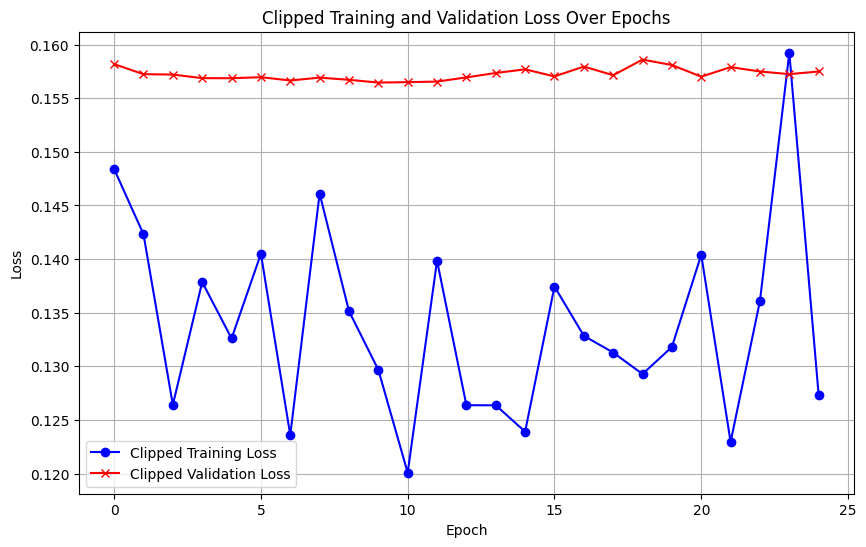

In [ ]:
import matplotlib.pyplot as plt

train_losses = trainer_result['train_loss']
val_losses = trainer_result['loss']  # Assuming 'loss' contains the validation losses

max_loss = 1  # Set a threshold for maximum loss to visualize

clipped_train_losses = [min(loss, max_loss) for loss in train_losses]
clipped_val_losses = [min(loss, max_loss) for loss in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(clipped_train_losses, label='Clipped Training Loss', color='blue', marker='o')
plt.plot(clipped_val_losses, label='Clipped Validation Loss', color='red', marker='x')
plt.title('Clipped Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched, collate_fn

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

!mkdir {RESULT_DIR}/Each_ckpt

### ⏭ Test score for all saved checkpoint.

In [ ]:
# Check the last five best epochs
if not user:
    model = model_post
    checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
    for checkpoint_path in checkpoint_paths[-5:]:
        state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
        state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("\nLoad model at: ", state_dict_path)
        #trainer = CryoEMTrainerWithScheduler(model, train_dataset, criterion, optimizer, device,
        #              num_classes=NUM_CLASSES,
        #              lr_scheduler=scheduler, patience=ES_PATIENCE)
        #result = trainer.evaluate(test_loader)
        model.to(DEVICE)
        model.eval()
        mini_batch_size = 9  # Number of patches to process at once
        with torch.no_grad():
            idx, (test_image, dnzd_test_image, _, grid, _) = next(enumerate(test_dataset))
            inputs = test_image.to(DEVICE)
            pairwise = dnzd_test_image.to(device) if (dnzd_test_image is not None) else None
            num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
            patched_outputs = []

            for batch_idx in range(num_batches):
                start_idx = batch_idx * mini_batch_size
                end_idx = min(start_idx + mini_batch_size, inputs.size(0))
                patch_input = inputs[start_idx:end_idx].to(DEVICE)
                patch_pairwise = pairwise[start_idx:end_idx].to(DEVICE) if (pairwise is not None) else None
                output = model(patch_input, patch_pairwise)['out']
                patched_outputs.append(output.cpu())  # Move to CPU to conserve GPU memory

                del patch_input
                torch.cuda.empty_cache()
            outputs = torch.cat(patched_outputs).to(DEVICE)  # Move to CPU to conserve GPU memory
            del patched_outputs
            torch.cuda.empty_cache()
            preds = outputs.argmax(dim=1).unsqueeze(1).cpu().detach()  # Now preds will have shape [81, 1, 512, 512]

            ## Plotting
            micrograph = np.load(f"{IMAGE_DIR}/val/{val_filenames[idx][:-4]}.npy")
            label_path = f"{LABEL_DIR}/{val_filenames[idx][:-4]}.png"


            micrograph_copy = simple_micrograph_preprocessing(micrograph)
            #crop_amount = 128  # Amount cropped from each side of the label image
            mic_width, mic_height = micrograph_copy.shape[1], micrograph_copy.shape[0]

            # Calculate starting and ending indices for cropping the micrograph
            #start_x = int((mic_width - 3840) / 2)
            #end_x = start_x + 3840
            #start_y = int((mic_height - 3840) / 2)
            #end_y = start_y + 3840

            # Crop the micrograph
            cropped_micrograph = micrograph_copy
            pred_image = reconstruct_patched(preds, grid).float()

            _,ax = plt.subplots(figsize=(12, 12))
            ax.imshow(cropped_micrograph, cmap='gray')
            ax.imshow(pred_image.squeeze(), cmap='inferno', alpha=0.4)
            plt.show()
            ##

            filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
            pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
            save_image(pred_image, pred_path)

### ✅ Testing

In [ ]:
# @markdown do testing
model = model_post
# dir_name = "unet_eb5_dice_CRF" # @param {type:"string"}
CHECKPOINT_PATH = RESULT_DIR

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/weight_test_rst/10017/unet_eb5_dice_CRF
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/weight_test_rst/10017/unet_eb5_dice_CRF/checkpoint10.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/weight_test_rst/10017/unet_eb5_dice_CRF/checkpoint10.pt


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    np.random.seed(24)
    selected_filenames = np.random.choice(test_filenames, size=6, replace=False)
    print(selected_filenames)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=selected_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
evaluator = CryoEMEvaluator(
    model=model, device=DEVICE, metrics=['AP','iou'],
    num_classes=NUM_CLASSES)
print("ConvCRF validation result:")
result = evaluator.evaluate(loader=val_loader)
if not user:
    print("ConvCRF test result:")
    result = evaluator.evaluate(loader=test_loader)

ConvCRF validation result:
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
Iou by Class: [0.87576747 0.63161933]
Precision by Class: [0.9411229  0.75413775]
Recall by Class: [0.92653066 0.7954093 ]
Accuracy by Class: [0.897583 0.897583]
F1_score by Class: [0.93376976 0.7742239 ]


In [ ]:
# @markdown ---
# @markdown time used
end_time = time.time()
print(f"End time recorded: {end_time}")

elapsed_time = end_time - start_time
elapsed_time = elapsed_time


hours = int(elapsed_time // 3600)
remaining_seconds = elapsed_time % 3600

minutes = int(remaining_seconds // 60)
seconds = round(remaining_seconds % 60, 3)

print(f"Time spend : {hours} h, {minutes} m, {seconds} s")


gpu_used = "L4" # @param ["CPU high", "T4", "T4 high", "L4"]
per_unit_cost_dict = {"L4" : 1.71, "T4 high" : 1.41, "T4" : 1.19, "CPU high" :  0.24}
per_unit_cost = per_unit_cost_dict[gpu_used]
print(f"unit price per hr {per_unit_cost}")

cost_units = per_unit_cost * elapsed_time / 3600

per_unit_US = 10.49 / 100

cost_price_US = cost_units * per_unit_US

print(f"unit cost : {round(cost_units, 4)}")
print(f"unit price US: {cost_price_US}")
print(f"unit price NTD: {cost_price_US * 30.76}")

End time recorded: 1764660216.165862
Time spend : 0 h, 18 m, 33.205 s
unit price per hr 1.71
unit cost : 0.5288
unit price US: 0.055468218165844685
unit price NTD: 1.7062023907813826
